# K-Nearest Neighbors (KNN)

## What is KNN?
KNN is a **non-parametric, lazy learning** algorithm it stores the entire training set and makes predictions by finding the $k$ nearest neighbors in feature space.

**Intuition**: Similar inputs should produce similar outputs.

---

## 1. Algorithm

Given a query point $x_q$:
1. Compute distance from $x_q$ to all training points
2. Find the $k$ nearest neighbors
3. **Classification**: majority vote → $\hat{y} = \text{mode}(y_{N_1}, \ldots, y_{N_k})$
4. **Regression**: average → $\hat{y} = \frac{1}{k}\sum_{i \in N_k} y_i$

---

## 2. Distance Metrics

### Euclidean Distance (L2)
$$d(x, z) = \sqrt{\sum_{i=1}^{n}(x_i - z_i)^2} = \|x - z\|_2$$

### Manhattan Distance (L1)
$$d(x, z) = \sum_{i=1}^{n}|x_i - z_i| = \|x - z\|_1$$

### Minkowski Distance (Generalization)
$$d(x, z) = \left(\sum_{i=1}^{n}|x_i - z_i|^p\right)^{1/p}$$

- $p=1$: Manhattan | $p=2$: Euclidean | $p\to\infty$: Chebyshev

### Cosine Similarity
$$\cos(x, z) = \frac{x \cdot z}{\|x\|\|z\|}$$

Cosine distance: $d = 1 - \cos(x, z)$ useful for text/high-dimensional data

### Hamming Distance
$$d(x, z) = \frac{1}{n}\sum_{i=1}^n \mathbb{1}[x_i \neq z_i]$$

For binary/categorical features.

### Mahalanobis Distance
$$d(x, z) = \sqrt{(x-z)^T S^{-1} (x-z)}$$

Where $S$ is the covariance matrix accounts for correlations between features.

---

## 3. Weighted KNN

Weight neighbors by inverse distance:

$$\hat{y} = \frac{\sum_{i \in N_k} w_i y_i}{\sum_{i \in N_k} w_i}, \quad w_i = \frac{1}{d(x_q, x_i)^2}$$

---

## 4. Curse of Dimensionality

In high dimensions:
- All points become equidistant
- Volume of space grows exponentially: to maintain density, need $n^d$ points for $d$ dimensions
- KNN degrades rapidly beyond ~10-20 features
- Solution: dimensionality reduction (PCA, UMAP) before KNN

---

## 5. Efficient Search Structures

### KD-Tree
Binary tree partitioning space along alternating dimensions. Complexity: $O(d \log n)$ average, $O(dn)$ worst case.

### Ball Tree
Partitions space into nested hyperspheres. Better for high-dimensional data.

### Approximate Nearest Neighbors
- **FAISS** (Facebook): GPU-accelerated, used in production RAG systems
- **ANNOY** (Spotify): memory-mapped, good for static datasets
- **HNSW**: Hierarchical Navigable Small World graphs state-of-the-art

---

## 6. Effect of k

- **Small k**: High variance, low bias (overfitting)
- **Large k**: Low variance, high bias (underfitting, smoother boundary)
- Rule of thumb: $k = \sqrt{n}$, use cross-validation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from collections import Counter
np.random.seed(42)

## KNN from Scratch

In [2]:
class KNNScratch:
    def __init__(self, k=5, metric='euclidean', weights='uniform'):
        self.k = k
        self.metric = metric
        self.weights = weights

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def _distance(self, a, b):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((a - b) ** 2))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(a - b))
        elif self.metric == 'cosine':
            return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

    def _predict_one(self, x):
        distances = [self._distance(x, xi) for xi in self.X_train]
        k_idx = np.argsort(distances)[:self.k]
        k_labels = self.y_train[k_idx]
        if self.weights == 'uniform':
            return Counter(k_labels).most_common(1)[0][0]
        else:  # distance-weighted
            k_dists = np.array([distances[i] for i in k_idx]) + 1e-10
            weights = 1 / k_dists ** 2
            weighted = {}
            for label, w in zip(k_labels, weights):
                weighted[label] = weighted.get(label, 0) + w
            return max(weighted, key=weighted.get)

    def predict(self, X):
        return np.array([self._predict_one(x) for x in X])


X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

for k in [1, 3, 5, 11]:
    knn = KNNScratch(k=k).fit(X_tr_s, y_train)
    acc = accuracy_score(y_test, knn.predict(X_te_s))
    print(f'k={k}: Scratch Acc={acc:.4f}')

k=1: Scratch Acc=1.0000
k=3: Scratch Acc=1.0000
k=5: Scratch Acc=1.0000
k=11: Scratch Acc=1.0000


## Mahalanobis Distance Comparison

The Mahalanobis distance accounts for feature correlations and different scales naturally, unlike Euclidean distance which treats all dimensions as independent and equally scaled. It transforms the data by the inverse covariance matrix, so correlated or differently-scaled features do not skew nearest-neighbor results. This makes it especially useful when features have different variances or are linearly correlated.

In [3]:
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# X_tr_s and X_te_s are the scaled Iris splits from above
# Compute covariance matrix on training data
X_train_scaled = X_tr_s
X_test_scaled  = X_te_s

cov = np.cov(X_train_scaled.T)
VI  = inv(cov)

# Compute Mahalanobis distance for first test point vs all training points
dists = [mahalanobis(X_test_scaled[0], x, VI) for x in X_train_scaled]
nearest_idx = np.argsort(dists)[:5]
print('5 nearest by Mahalanobis:', y_train[nearest_idx])
print('True label of test point:', y_test[0])

5 nearest by Mahalanobis: [1 2 1 1 1]
True label of test point: 1


## Effect of k Bias-Variance Tradeoff

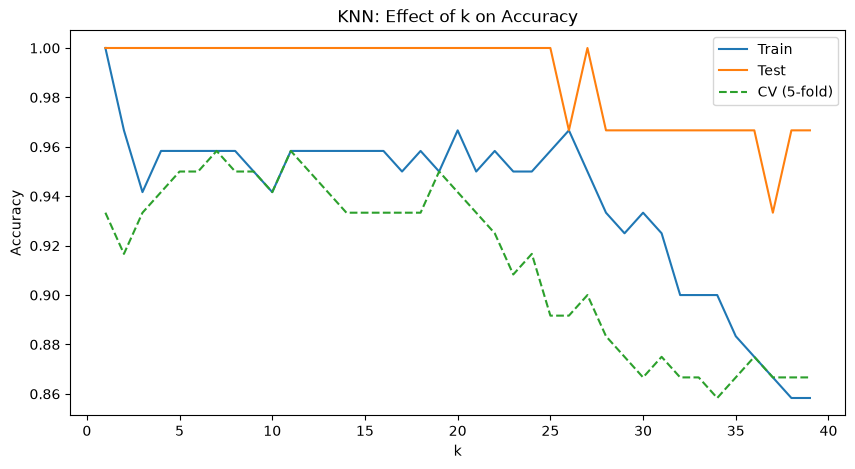

Best k by CV: 7, CV Acc: 0.9583


In [4]:
k_values = range(1, 40)
train_accs, test_accs, cv_accs = [], [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_s, y_train)
    train_accs.append(knn.score(X_tr_s, y_train))
    test_accs.append(knn.score(X_te_s, y_test))
    cv_accs.append(cross_val_score(knn, X_tr_s, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)).mean())

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accs, label='Train')
plt.plot(k_values, test_accs, label='Test')
plt.plot(k_values, cv_accs, label='CV (5-fold)', linestyle='--')
plt.xlabel('k'); plt.ylabel('Accuracy')
plt.title('KNN: Effect of k on Accuracy')
plt.legend(); plt.show()

best_k = k_values[np.argmax(cv_accs)]
print(f'Best k by CV: {best_k}, CV Acc: {max(cv_accs):.4f}')

## Distance Metric Comparison

In [5]:
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'cosine']
for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    score = cross_val_score(knn, X_tr_s, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)).mean()
    print(f'{metric:15s}: CV Acc = {score:.4f}')

euclidean      : CV Acc = 0.9500
manhattan      : CV Acc = 0.9417
chebyshev      : CV Acc = 0.9417
minkowski      : CV Acc = 0.9500
cosine         : CV Acc = 0.8417


## KD-Tree vs Ball Tree vs Brute Force')

In [6]:
import time

X_big, y_big = load_digits(return_X_y=True)
X_tr_big, X_te_big, y_tr_big, y_te_big = train_test_split(X_big, y_big, test_size=0.2, random_state=42)

for algo in ['brute', 'kd_tree', 'ball_tree']:
    start = time.time()
    knn = KNeighborsClassifier(n_neighbors=5, algorithm=algo)
    knn.fit(X_tr_big, y_tr_big)
    knn.predict(X_te_big)
    elapsed = time.time() - start
    print(f'{algo:10s}: Acc={knn.score(X_te_big, y_te_big):.4f}, Time={elapsed:.3f}s')

brute     : Acc=0.9861, Time=0.047s


kd_tree   : Acc=0.9861, Time=0.077s


ball_tree : Acc=0.9861, Time=0.057s


## KNN Regression

KNN regression works the same way as classification but instead of taking a majority vote, it averages the target values of the k nearest neighbors: $\hat{y} = \frac{1}{k}\sum_{i \in N_k} y_i$. Below we sweep k on the diabetes dataset and observe how RMSE and R2 change.

In [7]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import pandas as pd

X_reg, y_reg = load_diabetes(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

results = {}
for k in [1, 3, 5, 10, 20]:
    pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=k))])
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    results[k] = {
        'RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
        'R2':   r2_score(y_te, y_pred)
    }

reg_df = pd.DataFrame(results, index=['RMSE', 'R2']).T
reg_df.index.name = 'k'
print(reg_df.round(4))

       RMSE      R2
k                  
1   70.2792  0.0678
3   57.3326  0.3796
5   55.2037  0.4248
10  56.2881  0.4020
20  55.2123  0.4246


## Curse of Dimensionality

As random noise features are added, KNN accuracy degrades because all points become approximately equidistant in high-dimensional space. The signal from the original 2 informative features gets overwhelmed by the noise dimensions, making the nearest neighbor computation meaningless. This illustrates why dimensionality reduction (PCA, UMAP) is often applied before KNN in practice.

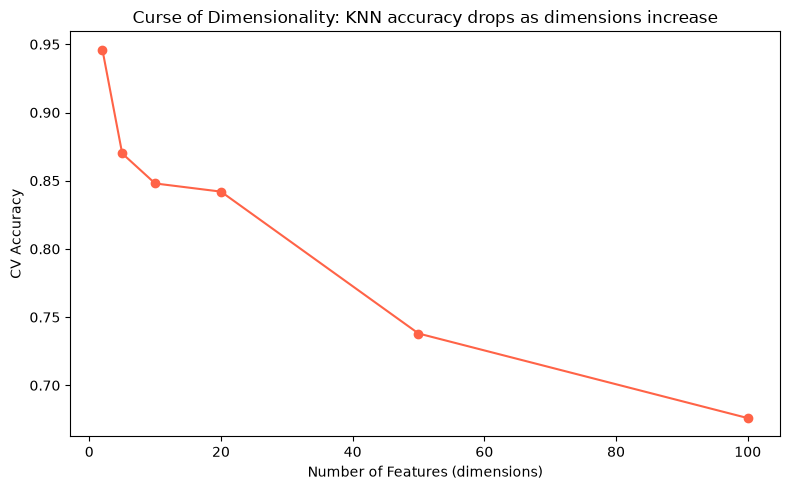

In [8]:
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier

base_X, base_y = make_classification(
    n_samples=500, n_features=2, n_informative=2,
    n_redundant=0, random_state=42
)

dimensions = [2, 5, 10, 20, 50, 100]
scores = []
for d in dimensions:
    if d > 2:
        noise = np.random.RandomState(42).randn(500, d - 2)
        X_d = np.hstack([base_X, noise])
    else:
        X_d = base_X
    knn = KNeighborsClassifier(n_neighbors=5)
    score = cross_val_score(
        knn, X_d, base_y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    ).mean()
    scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(dimensions, scores, marker='o', color='tomato')
plt.xlabel('Number of Features (dimensions)')
plt.ylabel('CV Accuracy')
plt.title('Curse of Dimensionality: KNN accuracy drops as dimensions increase')
plt.tight_layout()
plt.show()

## Approximate Nearest Neighbors (ANN)

Exact KNN becomes too slow for large datasets: $O(nd)$ per query is infeasible when $n$ is in the millions. Approximate methods trade a small accuracy loss for orders-of-magnitude speedup. Use cases include: recommendation systems (item/user embeddings), semantic search over sentence embeddings, image retrieval, and RAG pipelines where a vector database must serve thousands of queries per second. Libraries to know:

- **FAISS** (Meta): GPU-accelerated, industry standard for dense vectors
- **ANNOY** (Spotify): memory-mapped forest of random projection trees, good for static datasets
- **HNSW** (hnswlib / pgvector): state-of-the-art graph-based index, best recall/speed tradeoff
- **sklearn ball_tree / kd_tree**: exact but faster than brute force for moderate $d$

In [9]:
try:
    import faiss
    print('FAISS available')
except ImportError:
    print('FAISS not installed. In production use: pip install faiss-cpu')
    print('Alternative: use sklearn.neighbors with algorithm="ball_tree" or "kd_tree"')

FAISS not installed. In production use: pip install faiss-cpu
Alternative: use sklearn.neighbors with algorithm="ball_tree" or "kd_tree"


## Additional Learning Resources

### Papers
- 📄 [Fix & Hodges (1951)](https://apps.dtic.mil/dtic/tr/fulltext/u2/a800276.pdf) Original KNN paper
- 📄 [Cover & Hart (1967) Nearest Neighbor Pattern Classification](https://ieeexplore.ieee.org/document/1053964)
- 📄 [FAISS: Billion-scale similarity search](https://arxiv.org/abs/1702.08734)
- 📄 [HNSW: Efficient and robust ANN](https://arxiv.org/abs/1603.09320)

### Videos
- 🎥 [StatQuest: KNN](https://www.youtube.com/watch?v=HVXime0nQeI)
- 🎥 [KNN from Scratch (Normalized)](https://www.youtube.com/watch?v=rTEtEy5o3X0)

### Documentation
- 📚 [Scikit-Learn Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html)
- 📚 [FAISS Documentation](https://faiss.ai/)
- 📚 [ANNOY Documentation](https://github.com/spotify/annoy)